In [ ]:
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
qml.drawer.use_style('black_white')
from functools import reduce
from Carlemann import Burgers_Carlemann

In [2]:
import pyqsp
from pyqsp.angle_sequence import QuantumSignalProcessingPhases
kappa = 8
pcoeffs, s = pyqsp.poly.PolyOneOverX().generate(kappa, return_coef=True, ensure_bounded=True, return_scale=True)
phi_pyqsp = QuantumSignalProcessingPhases(pcoeffs, signal_operator='Wx', tolerance=0.00001)
phi_qsvt = qml.transform_angles(phi_pyqsp, "QSP", "QSVT")
len(phi_qsvt)

b=280, j0=51
[PolyOneOverX] minimum [-10.69067105] is at [-0.06701114]: normalizing
[PolyOneOverX] bounding to 0.9


560

In [3]:
# Combination to see the results are N_T = 4, N = 12, total time = 0.15, and dtype = np.float32
# For quantum testing N_T = 2, N = 5, total time = 0.2, dtype = np.float32
N = 5
N_T = 2
u0 = 0
uN1 = 0
total_time = 0.3
mu = 0.01
dt = 0.1
burgers_carlemann = Burgers_Carlemann(N, N_T, total_time, mu, dt, u0, uN1, stencil="method_2")
x, dx = burgers_carlemann.get_x_dx()

In [4]:
A_desired = burgers_carlemann.get_I_m_Adt()
print(f"Shape of A : {A_desired.shape}")

Shape of A : (30, 30)


In [5]:
def get_A_inv_default_circuit(L, phi, s):
    block_encode = qml.BlockEncode(L, wires=range(6))
    projectors = [
        qml.PCPhase(phi[i], dim=len(L), wires=range(6))
        for i in range(len(phi))
    ]
    qml.QSVT(block_encode, projectors)
    return qml.state()

In [6]:
def get_A_inv_default(L, phi, s):
    block_encode = qml.BlockEncode(L, wires=range(6))
    factor = block_encode.hyperparameters["norm"]
    t = qml.matrix(get_A_inv_default_circuit, wire_order=range(6))(L, phi, s)
    t = t[:L.shape[0], :L.shape[1]]
    A_inv_default = t/(s*factor)
    return A_inv_default

In [7]:
def get_A_inv_psi_default_circuit(L, phi, psi_normalized):
    # Assuming square matrix
    block_encode = qml.BlockEncode(L, wires=range(6))
    projectors = [
        qml.PCPhase(phi[i], dim=len(L), wires=range(6))
        for i in range(len(phi))
    ]
    qml.StatePrep(psi_normalized, wires=range(1, 6))
    qml.QSVT(block_encode, projectors)
    return qml.state()

In [8]:
def get_A_inv_psi_default(L, psi_state, phi, s):
    psi_norm = np.linalg.norm(psi_state, 2)
    psi_normalized = psi_state/psi_norm
    #n_wires, block_encode, factor = self.get_n_wires_default(L)
    block_encode = qml.BlockEncode(L, wires=range(6))
    factor = block_encode.hyperparameters["norm"]
    dev = qml.device("default.qubit", wires=range(6))
    circuit = qml.QNode(get_A_inv_psi_default_circuit, dev)
    t = circuit(L, phi, psi_normalized)
    #t = np.real(t[:psi_normalized.shape[0]])
    t = t[:psi_normalized.shape[0]].real
    state_inverse_default = t*(psi_norm)/(s*factor)
    return state_inverse_default

In [25]:
# success probability
def get_success_probability(L, psi_normalized, s):
    L_scaled = L/np.linalg.norm(L, 2)
    U,S,V = np.linalg.svd(L_scaled.T)
    overlap = []
    for i in range(V.shape[0]):
        t = np.dot(V.T[:, i], psi_normalized)
        overlap.append(t)
    b_v = np.array(overlap)
    t = (b_v*s)*(1/S)
    t = np.sum(t**2)
    return t

In [41]:
def get_implicit_solver_modify():
    y_init = burgers_carlemann.get_y_init()
    n_timesteps = int(np.round(burgers_carlemann.TOTAL_TIME/burgers_carlemann.DT))
    A = burgers_carlemann.get_I_m_Adt()
    B = burgers_carlemann.get_B()
    u = burgers_carlemann.get_u_desired()
    A_t = np.eye(32)
    A_t[:A.shape[0], :A.shape[1]] = A
    y_store = []
    RMSE_list = []
    p_success_list = []
    t = np.concat(([burgers_carlemann.U0], y_init[:burgers_carlemann.N], [burgers_carlemann.UN1]), dtype=burgers_carlemann.DTYPE)
    y_prev = y_init.copy()
    y_store.append(t)
    for i in range(n_timesteps):
        print(f"Time step {i+1}/{n_timesteps}")
        L = y_prev + B*burgers_carlemann.DT
        #y_prev = np.linalg.solve(A, L)
        L = np.concatenate((L, [0, 0]))
        L_normalized = L/np.linalg.norm(L, 2)
        p_s = get_success_probability(A_t, L_normalized, s)
        p_success_list.append(p_s)
        y_prev = get_A_inv_psi_default(A_t.T, L, phi_qsvt, s)
        #y_prev = np.linalg.solve(A_t, L)
        y_prev = y_prev[:30].real
        t = np.sum((y_prev[:burgers_carlemann.N] - u[1:-1, i+1])**2)
        t = np.sqrt(t/burgers_carlemann.N)
        RMSE_list.append(t)
        t = np.concat(([burgers_carlemann.U0], y_prev[:burgers_carlemann.N], [burgers_carlemann.UN1]), dtype=burgers_carlemann.DTYPE)
        y_store.append(t)
    RMSE_list = np.array(RMSE_list)
    return y_store, RMSE_list, p_success_list

Time step 1/3
Time step 2/3
Time step 3/3


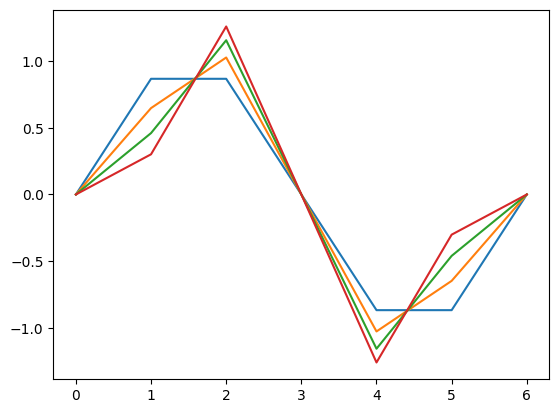

In [42]:
y_store, RMSE_list, p_success_list = get_implicit_solver_modify()
for i in range(4):
    plt.plot(y_store[i], label=f"Time step {i}")

In [43]:
y_ideal, rmse_ideal = burgers_carlemann.get_implicit_solver()

Time step 1/3
Time step 2/3
Time step 3/3


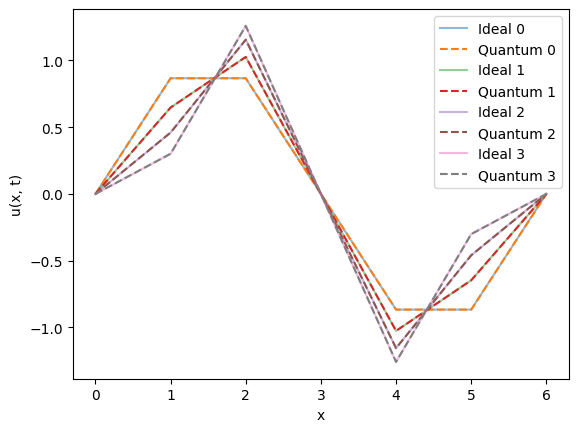

In [44]:
for i in range(len(y_ideal)):
    plt.plot(y_ideal[i], alpha=0.5, label=f"Ideal {i}")
    plt.plot(y_store[i], label=f"Quantum {i}", linestyle='dashed')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.legend()

In [45]:
p_success_list = np.array(p_success_list)
p_success_list

array([0.01194286, 0.0122345 , 0.01246017])